# 성능 비교 시각화 v1_2 — 2026-04-30

**담당:** 경이 (kyeongyi)  
**목적:** v1 데이터(split_v1.csv) 기준으로 Simple vs **KcELECTRA v1_2 (beomi/kcelectra-base)** 성능을 시각화.

> **[모델 명칭]**  
> KcELECTRA v1_2 = `beomi/kcelectra-base` (이준범 제작, 진짜 KcELECTRA-base)  
> KcELECTRA v1 = `monologg/koelectra-small-v3-discriminator` (KoELECTRA-small, 이름만 KcELECTRA였음)

## 실행 전 체크리스트
- [ ] `evaluate_compare_v1_2_20260430.py` 실행 완료 (Simple 평가)
- [ ] `data/20260430/eval_results_simple_v1_2_20260430.json` 존재
- [ ] `data/20260430/eval_results_kcelectra_v1_2_20260430.json` 존재 (Colab 완료 후)

## 생성 파일 (data/20260430/)
- `compare_macro_f1_v1_2_20260430.png` — Macro F1 막대 비교
- `compare_per_class_f1_v1_2_20260430.png` — 카테고리별 F1 비교
- `compare_confusion_matrix_v1_2_20260430.png` — Confusion Matrix 나란히
- `compare_radar_f1_v1_2_20260430.png` — 레이더 차트
- `compare_precision_recall_f1_v1_2_20260430.png` — Precision/Recall/F1 종합

In [1]:
# 셀 1: 경로 설정 + 데이터 로드
import json
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import platform
import seaborn as sns

# 한글 폰트 설정
if platform.system() == "Windows":
    matplotlib.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":
    matplotlib.rc("font", family="AppleGothic")
else:
    try:
        import subprocess
        import matplotlib.font_manager as fm
        subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        matplotlib.rc("font", family=prop.get_name())
    except Exception:
        pass
matplotlib.rcParams["axes.unicode_minus"] = False

# 경로 설정 (로컬 / Colab 모두 지원)
_NB   = Path(".").resolve()
_BASE = _NB.parent if _NB.name == "notebooks" else _NB
OUT   = _BASE / "data" / "20260430"
OUT.mkdir(parents=True, exist_ok=True)

SIMPLE_JSON = OUT / "eval_results_simple_v1_2_20260430.json"
KC_JSON     = OUT / "eval_results_kcelectra_v1_2_20260430.json"

if not SIMPLE_JSON.exists():
    raise FileNotFoundError(f"{SIMPLE_JSON} 없음 -- evaluate_compare_v1_2_20260430.py 먼저 실행")

with open(SIMPLE_JSON, encoding="utf-8") as f:
    simple = json.load(f)

kc = None
if KC_JSON.exists():
    with open(KC_JSON, encoding="utf-8") as f:
        kc = json.load(f)
    print("[로드] KcELECTRA v1_2 결과 있음 (beomi/kcelectra-base)")
else:
    print("[주의] KcELECTRA v1_2 JSON 없음 -- Simple 결과만 시각화합니다.")
    print("  Colab에서 01_train_kcelectra_v1_2_20260430.ipynb 실행 후 재시도")

LABELS = ["일정", "준비물", "제출", "비용", "건강·안전", "기타"]

simple_f1 = simple["macro_f1"]
kc_f1     = kc["macro_f1"] if kc else None
delta     = kc_f1 - simple_f1 if kc else None

print(f"Simple v1_2 Macro F1: {simple_f1:.4f}")
if kc:
    print(f"KcELECTRA v1_2 (beomi/kcelectra-base) Macro F1: {kc_f1:.4f}")
    print(f"Delta: {delta:+.4f}")

[로드] KcELECTRA v1_2 결과 있음 (beomi/kcelectra-base)
Simple v1_2 Macro F1: 0.8450
KcELECTRA v1_2 (beomi/kcelectra-base) Macro F1: 0.5310
Delta: -0.3140


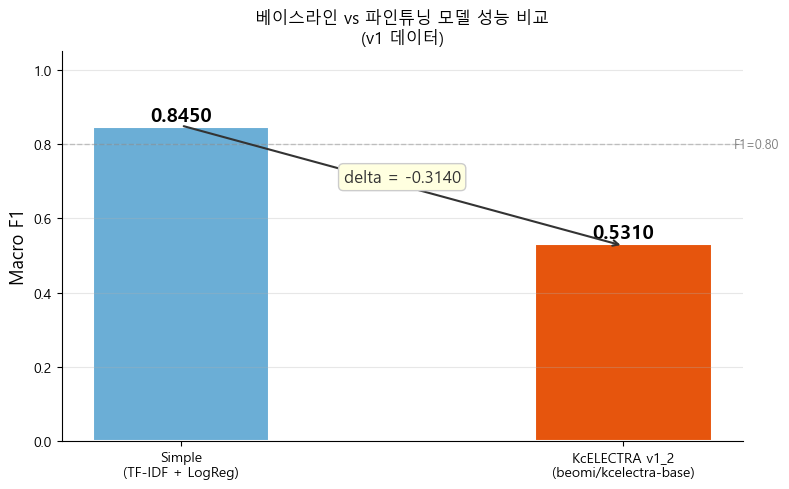

저장: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260430\compare_macro_f1_v1_2_20260430.png


In [2]:
# 셀 2: [그래프 1] Macro F1 막대 비교 — 핵심 지표

if kc is None:
    print("KcELECTRA 결과가 없어 Simple 단독 시각화만 수행합니다.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))

    models  = ["Simple\n(TF-IDF + LogReg)", "KcELECTRA v1_2\n(beomi/kcelectra-base)"]
    f1s     = [simple_f1, kc_f1]
    colors  = ["#6baed6", "#e6550d"]

    bars = ax.bar(models, f1s, color=colors, width=0.4, edgecolor="white", linewidth=1.5)

    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=14, fontweight="bold")

    ax.annotate("",
                xy=(1, kc_f1 - 0.005),
                xytext=(0, simple_f1 + 0.005),
                arrowprops=dict(arrowstyle="->", color="#333333", lw=1.5))
    mid_y = (simple_f1 + kc_f1) / 2
    ax.text(0.5, mid_y, f"delta = {delta:+.4f}",
            ha="center", va="bottom", fontsize=12, color="#333333",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="#cccccc"))

    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Macro F1", fontsize=13)
    ax.set_title("베이스라인 vs 파인튜닝 모델 성능 비교\n(v1 데이터)", fontsize=12)
    ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.4, linewidth=1)
    ax.text(1.25, 0.8, "F1=0.80", color="gray", fontsize=9, va="center")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    out_path = OUT / "compare_macro_f1_v1_2_20260430.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")

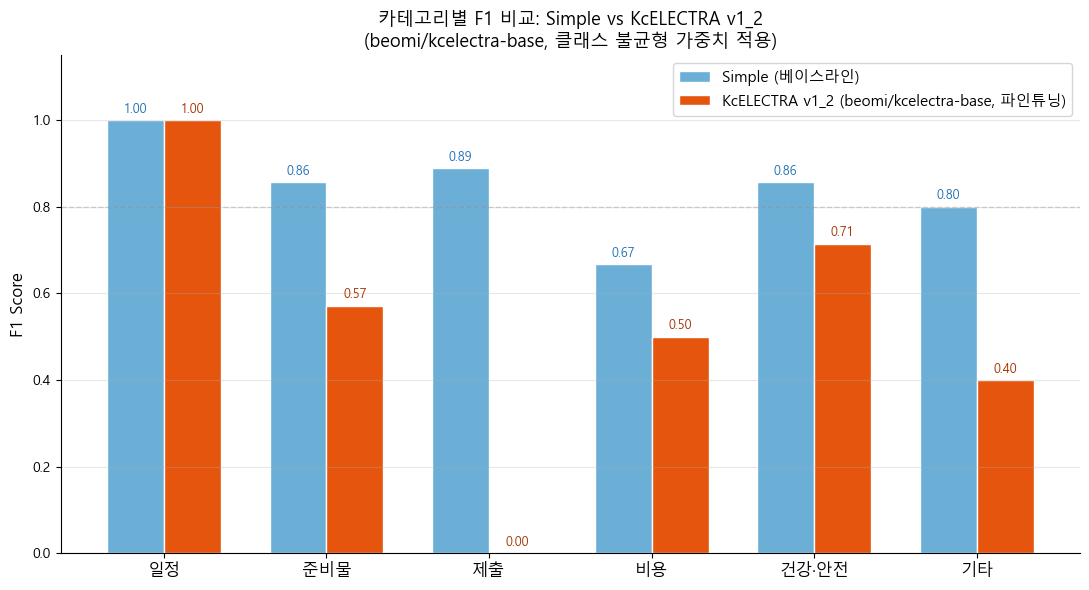

저장: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260430\compare_per_class_f1_v1_2_20260430.png


In [3]:
# 셀 3: [그래프 2] 카테고리별 F1 비교 (grouped bar)

if kc is None:
    print("KcELECTRA 결과 없음 -- 스킵")
else:
    s_f1s = [simple["per_class"][lbl]["f1"] for lbl in LABELS]
    k_f1s = [kc["per_class"][lbl]["f1"] for lbl in LABELS]

    x = np.arange(len(LABELS))
    w = 0.35

    fig, ax = plt.subplots(figsize=(11, 6))
    bars1 = ax.bar(x - w/2, s_f1s, w, label="Simple (베이스라인)", color="#6baed6", edgecolor="white")
    bars2 = ax.bar(x + w/2, k_f1s, w, label="KcELECTRA v1_2 (beomi/kcelectra-base, 파인튜닝)", color="#e6550d", edgecolor="white")

    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=9, color="#2171b5")
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=9, color="#a63603")

    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("F1 Score", fontsize=12)
    ax.set_title("카테고리별 F1 비교: Simple vs KcELECTRA v1_2\n(beomi/kcelectra-base, 클래스 불균형 가중치 적용)", fontsize=13)
    ax.legend(fontsize=11)
    ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.3, linewidth=1)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    out_path = OUT / "compare_per_class_f1_v1_2_20260430.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")

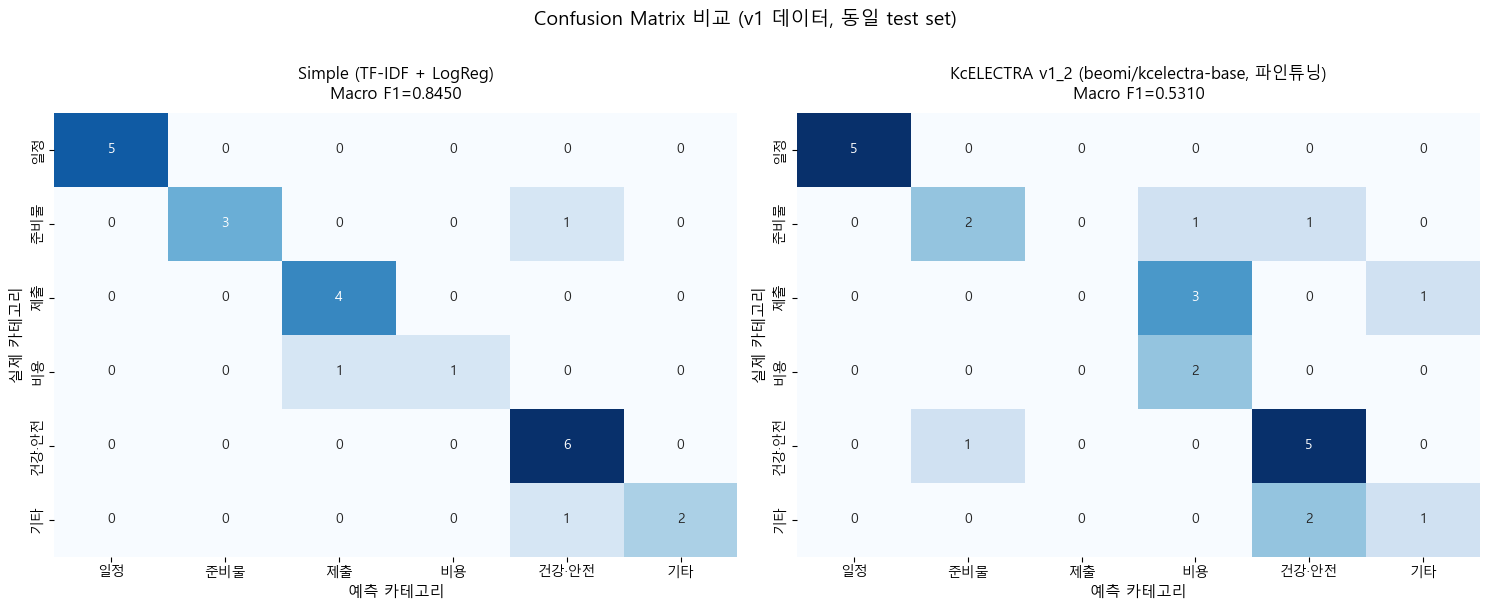

저장: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260430\compare_confusion_matrix_v1_2_20260430.png


In [4]:
# 셀 4: [그래프 3] Confusion Matrix 나란히

if kc is None:
    print("KcELECTRA 결과 없음 -- Simple CM만 출력")
    s_cm = np.array(simple["confusion_matrix"])
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(s_cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False)
    ax.set_xlabel("예측 카테고리", fontsize=11)
    ax.set_ylabel("실제 카테고리", fontsize=11)
    ax.set_title(f"Simple Confusion Matrix (Macro F1={simple_f1:.4f})", fontsize=12)
    plt.tight_layout()
    out_path = OUT / "confusion_matrix_simple_v1_2_20260430.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")
else:
    s_cm = np.array(simple["confusion_matrix"])
    k_cm = np.array(kc["confusion_matrix"])

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, cm_data, title in [
        (axes[0], s_cm, f"Simple (TF-IDF + LogReg)\nMacro F1={simple_f1:.4f}"),
        (axes[1], k_cm, f"KcELECTRA v1_2 (beomi/kcelectra-base, 파인튜닝)\nMacro F1={kc_f1:.4f}"),
    ]:
        sns.heatmap(cm_data, annot=True, fmt="d", cmap="Blues",
                    xticklabels=LABELS, yticklabels=LABELS,
                    ax=ax, cbar=False)
        ax.set_xlabel("예측 카테고리", fontsize=11)
        ax.set_ylabel("실제 카테고리", fontsize=11)
        ax.set_title(title, fontsize=12, pad=10)

    plt.suptitle("Confusion Matrix 비교 (v1 데이터, 동일 test set)", fontsize=14, y=1.01)
    plt.tight_layout()
    out_path = OUT / "compare_confusion_matrix_v1_2_20260430.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")

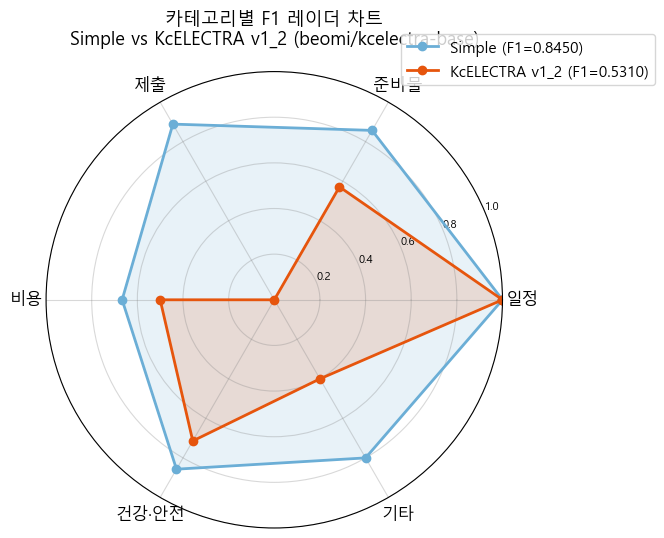

저장: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260430\compare_radar_f1_v1_2_20260430.png


In [5]:
# 셀 5: [그래프 4] 레이더 차트

if kc is None:
    print("KcELECTRA 결과 없음 -- 스킵")
else:
    angles = np.linspace(0, 2 * np.pi, len(LABELS), endpoint=False).tolist()
    angles += angles[:1]

    s_vals = [simple["per_class"][lbl]["f1"] for lbl in LABELS] + [simple["per_class"][LABELS[0]]["f1"]]
    k_vals = [kc["per_class"][lbl]["f1"] for lbl in LABELS]     + [kc["per_class"][LABELS[0]]["f1"]]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    ax.plot(angles, s_vals, "o-", linewidth=2, color="#6baed6", label=f"Simple (F1={simple_f1:.4f})")
    ax.fill(angles, s_vals, alpha=0.15, color="#6baed6")

    ax.plot(angles, k_vals, "o-", linewidth=2, color="#e6550d", label=f"KcELECTRA v1_2 (F1={kc_f1:.4f})")
    ax.fill(angles, k_vals, alpha=0.15, color="#e6550d")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(LABELS, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
    ax.set_title("카테고리별 F1 레이더 차트\nSimple vs KcELECTRA v1_2 (beomi/kcelectra-base)",
                 fontsize=13, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=11)
    ax.grid(color="gray", alpha=0.3)

    plt.tight_layout()
    out_path = OUT / "compare_radar_f1_v1_2_20260430.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")

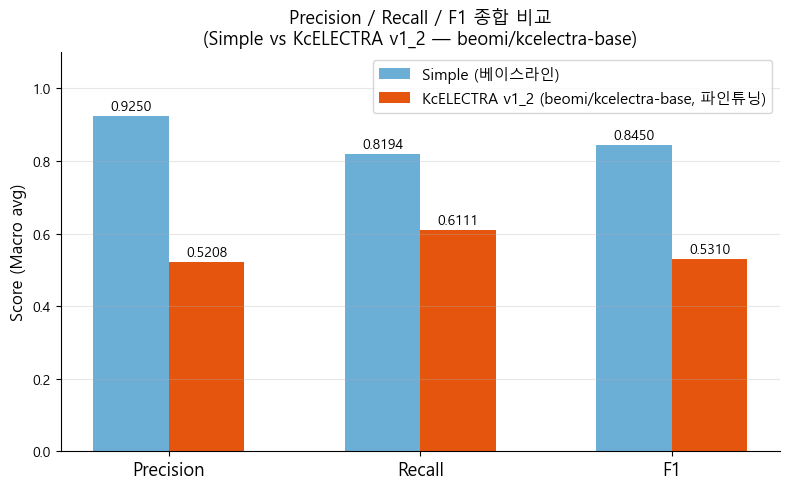

저장: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260430\compare_precision_recall_f1_v1_2_20260430.png


In [6]:
# 셀 6: [그래프 5] Precision / Recall / F1 종합 비교

if kc is None:
    print("KcELECTRA 결과 없음 -- 스킵")
else:
    metrics = ["Precision", "Recall", "F1"]
    s_vals  = [simple["macro_precision"], simple["macro_recall"],  simple["macro_f1"]]
    k_vals  = [kc["macro_precision"],     kc["macro_recall"],      kc["macro_f1"]]

    x = np.arange(len(metrics))
    w = 0.3

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x - w/2, s_vals, w, label="Simple (베이스라인)", color="#6baed6")
    bars2 = ax.bar(x + w/2, k_vals, w, label="KcELECTRA v1_2 (beomi/kcelectra-base, 파인튜닝)", color="#e6550d")

    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f"{h:.4f}", ha="center", va="bottom", fontsize=10)
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f"{h:.4f}", ha="center", va="bottom", fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=13)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score (Macro avg)", fontsize=12)
    ax.set_title("Precision / Recall / F1 종합 비교\n(Simple vs KcELECTRA v1_2 — beomi/kcelectra-base)", fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    out_path = OUT / "compare_precision_recall_f1_v1_2_20260430.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")

In [7]:
# 셀 7: 최종 요약 출력

SIMPLE_BASELINE_F1 = 0.845

print("=" * 65)
print("  최종 성능 비교 요약 (v1 데이터)")
print("  KcELECTRA v1_2: beomi/kcelectra-base")
print("=" * 65)
print()

if kc:
    print(f"  {'지표':15s} {'Simple v1_2':>14s} {'KcELECTRA v1_2':>16s} {'delta':>8s}")
    print("  " + "-" * 58)

    rows = [
        ("Macro Precision", simple["macro_precision"], kc["macro_precision"]),
        ("Macro Recall",    simple["macro_recall"],    kc["macro_recall"]),
        ("Macro F1",        simple["macro_f1"],        kc["macro_f1"]),
    ]
    for name, s, k_val in rows:
        d = k_val - s
        mark = "★" if d >= 0.05 else ("up" if d > 0 else "down")
        print(f"  {name:15s} {s:>14.4f} {k_val:>16.4f} {d:>+7.4f} {mark}")

    print("  " + "-" * 58)
    print(f"\n  {'카테고리':10s} {'Simple F1':>10s} {'KcELEC F1':>11s} {'delta':>7s}")
    print("  " + "-" * 44)
    for lbl in LABELS:
        s = simple["per_class"][lbl]["f1"]
        k_val = kc["per_class"][lbl]["f1"]
        d = k_val - s
        sup = kc["per_class"][lbl]["support"]
        mark = "up" if d > 0.02 else ("down" if d < -0.02 else "~")
        print(f"  {lbl:10s} {s:>10.4f} {k_val:>11.4f} {d:>+6.4f} {mark}  (test {int(sup)}건)")

    print("\n" + "=" * 65)
    delta_main = kc["macro_f1"] - simple_f1
    delta_base = kc["macro_f1"] - SIMPLE_BASELINE_F1
    if delta_main >= 0.05:
        print(f"  결론: KcELECTRA v1_2 (beomi)이 Simple v1_2 대비 {delta_main:+.4f} (5%+ 달성!)")
    elif delta_main > 0:
        print(f"  결론: KcELECTRA v1_2 (beomi)이 Simple v1_2 대비 {delta_main:+.4f} 향상")
    else:
        print(f"  결론: Simple이 더 높음 (delta={delta_main:.4f}) — 재학습 필요")
    print(f"  (Simple 기준값({SIMPLE_BASELINE_F1}) 대비: {delta_base:+.4f})")
    print("=" * 65)
else:
    print(f"  Simple v1_2 Macro F1: {simple_f1:.4f}")
    print(f"  KcELECTRA v1_2: 아직 미완료 (Colab 학습 필요)")
    print()
    print(f"  [v1_2 Simple 카테고리별 F1]")
    for lbl in LABELS:
        s = simple["per_class"][lbl]["f1"]
        sup = simple["per_class"][lbl]["support"]
        print(f"  {lbl:10s} {s:.4f}  (test {int(sup)}건)")
    print("=" * 65)

  최종 성능 비교 요약 (v1 데이터)
  KcELECTRA v1_2: beomi/kcelectra-base

  지표                 Simple v1_2   KcELECTRA v1_2    delta
  ----------------------------------------------------------
  Macro Precision         0.9250           0.5208 -0.4042 down
  Macro Recall            0.8194           0.6111 -0.2083 down
  Macro F1                0.8450           0.5310 -0.3140 down
  ----------------------------------------------------------

  카테고리        Simple F1   KcELEC F1   delta
  --------------------------------------------
  일정             1.0000      1.0000 +0.0000 ~  (test 5건)
  준비물            0.8571      0.5714 -0.2857 down  (test 4건)
  제출             0.8889      0.0000 -0.8889 down  (test 4건)
  비용             0.6667      0.5000 -0.1667 down  (test 2건)
  건강·안전          0.8571      0.7143 -0.1428 down  (test 6건)
  기타             0.8000      0.4000 -0.4000 down  (test 3건)

  결론: Simple이 더 높음 (delta=-0.3140) — 재학습 필요
  (Simple 기준값(0.845) 대비: -0.3140)
